In [1]:
import shap
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib
import numpy as np


In [2]:
predictions = pd.read_parquet('predictions.parquet', engine='pyarrow')
predictions.head()

,id,clean_text,text,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,democrat,positive


In [3]:
train = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
train.head()

,clean_text,party,sentiment,sentiment_score
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,0.8479
1,favorite post kamala harris pretending like de...,democrat,positive,0.8545
2,ron desantis signed sb304 price gouging back a...,democrat,positive,0.8979
3,200 people dead hurricane 99 republican voted ...,republican,negative,-0.8662
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,-0.9712


## Party Classifier

In [4]:
X_train, y_train = train['clean_text'], train['party']
X_test, y_test = predictions['clean_text'], predictions['party']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

50000
36029216
0.0013877626424066514


In [5]:
print(len(X_sample_test))
print(len(y_sample_test))

50000
50000


In [6]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")
tfidf = party_model.named_steps["tfidf"]
lgb_model = party_model.named_steps["clf"]

X_sample_test_tfidf = tfidf.transform(X_sample_test)

In [7]:
print("TF-IDF shape:", X_sample_test_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF shape: (50000, 20000)
Number of features: 20000


In [8]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_sample_test_tfidf)

In [9]:
print(type(shap_values.values), shap_values.values.shape)


<class 'scipy.sparse._csr.csr_matrix'> (50000, 20000)


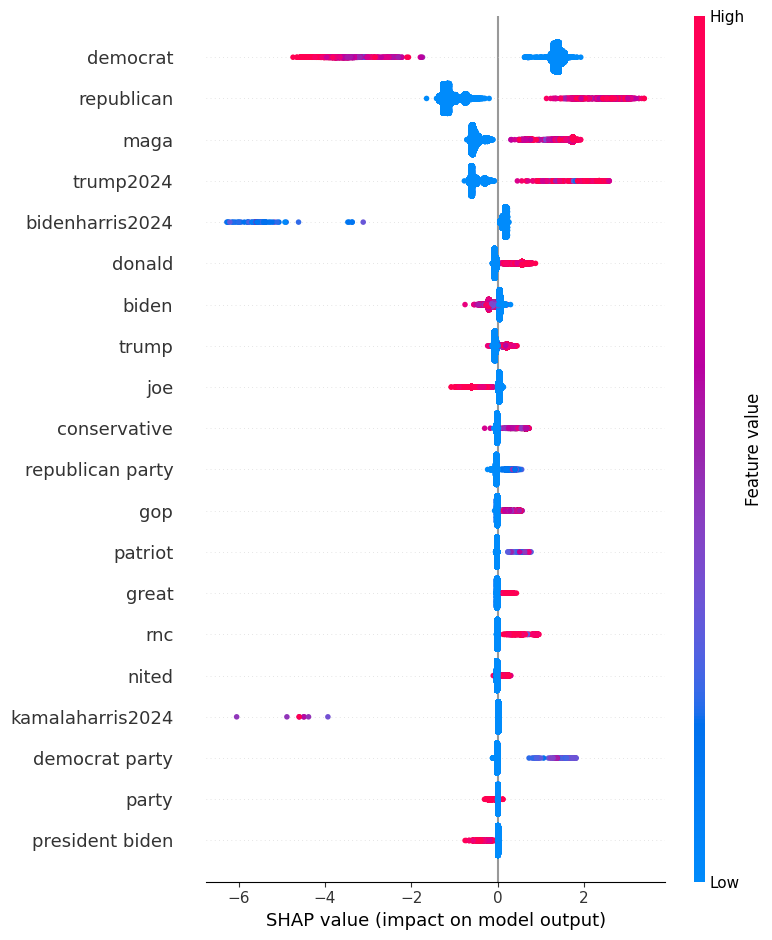

In [10]:
feature_names = tfidf.get_feature_names_out()

shap_dense = shap_values.values.toarray()  # shape: (10000, 20000)
X_dense = X_sample_test_tfidf.toarray()

shap.initjs()

shap.summary_plot(shap_dense, features=X_dense, feature_names=feature_names)


In [11]:
# shap.initjs()

# shap.plots.bar(shap.Explanation(values=shap_values[1000], 
#                                 base_values=explainer.expected_value,
#                                 feature_names=feature_names))

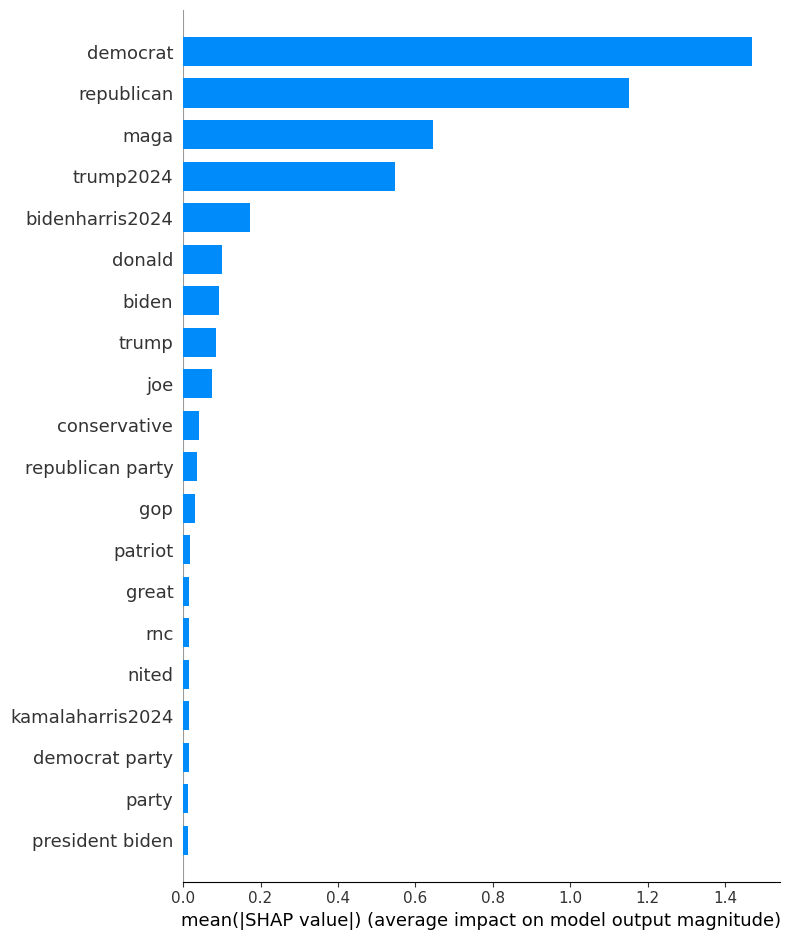

In [12]:
# Mean absolute SHAP values per feature
mean_abs_shap = np.abs(shap_dense).mean(axis=0)

# Top 50 features
top_idx = np.argsort(mean_abs_shap)[-50:]
feature_names_top = feature_names[top_idx]
shap_top = shap_dense[:, top_idx]
X_top = X_dense[:, top_idx]

# Global feature importance bar plot
shap.summary_plot(shap_top, features=X_top, feature_names=feature_names_top, plot_type="bar")


In [13]:
# Check class encoding
print("Class labels:", lgb_model.classes_)
print("Positive class (index 1):", lgb_model.classes_[1])
print("Negative class (index 0):", lgb_model.classes_[0])


Class labels: ['democrat' 'republican']
Positive class (index 1): republican
Negative class (index 0): democrat


In [14]:
# Find the "democrat" feature index
democrat_idx = np.where(feature_names == 'democrat')[0][0]
print(f"'democrat' feature index: {democrat_idx}")

'democrat' feature index: 4524


In [15]:
feature_importance = []

for i, feature_name in enumerate(feature_names):
    feature_vals = X_dense[:, i]
    shap_vals = shap_dense[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Mean_SHAP_When_Present': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'republican' if mean_shap_when_present > 0 else 'democrat'
        })

df = pd.DataFrame(feature_importance).sort_values(
    by='Mean_SHAP_When_Present', 
    ascending=False
)


In [16]:
print("Directional Importance (top 10 pushing toward REPUBLICAN):")
df.head(10)

Directional Importance (top 10 pushing toward REPUBLICAN):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
13528,republican,2.559829,1589,republican
10086,magacultmorons,2.089745,9,republican
16970,trump2024,2.060670,877,republican
9919,maga,1.557307,5791,republican
5619,every democrat,1.557072,11,republican
4314,democrat administration,1.534791,1,republican
13710,republicanism,1.521981,2,republican
10085,magacult,1.476824,8,republican
4482,democrat party,1.462470,112,republican
17008,trump2024istheonlychoice,1.370396,3,republican


In [17]:
print("Directional Importance (top 10 pushing toward DEMOCRAT):")
df.tail(10)

Directional Importance (top 10 pushing toward DEMOCRAT):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
4624,democratscheat,-1.782479,2,democrat
15997,thedemocrats,-1.857882,4,democrat
2221,bidenharris2024toprotectdemocracy,-1.951995,4,democrat
4622,democratsareevil,-2.019919,2,democrat
4625,democratsdividinganddestroyingamerica,-2.122125,2,democrat
4621,democratsaredestroyingamerica,-2.802426,3,democrat
4626,democratshateamerica,-2.990845,5,democrat
4308,democrat,-3.644132,1904,democrat
8786,kamalaharris2024,-4.677064,8,democrat
2219,bidenharris2024,-5.483779,114,democrat


In [18]:
# # Find all original texts where "democrat party" feature is present

# # 1. Find the feature index
# try:
#     democrat_party_idx = np.where(feature_names == 'democrat party')[0][0]
#     print(f"'democrat party' feature index: {democrat_party_idx}")
# except IndexError:
#     print("Feature 'democrat party' not found.")
#     matching = [f for f in feature_names if 'democrat' in f and 'party' in f]
#     print(f"Similar features: {matching}")
#     if matching:
#         democrat_party_idx = np.where(feature_names == matching[0])[0][0]
#         print(f"Using: '{matching[0]}' at index {democrat_party_idx}")
#     else:
#         raise ValueError("No matching feature found")

# # 2. Get feature values and SHAP values
# democrat_party_feature_vals = X_dense[:, democrat_party_idx]
# democrat_party_shap_vals = shap_dense[:, democrat_party_idx]

# # 3. Find samples where feature is present (non-zero)
# present_mask = democrat_party_feature_vals > 0
# present_indices = sample_indices[present_mask]  # Convert back to original indices

# print(f"\nNumber of samples with 'democrat party': {present_mask.sum()}")

# # 4. Get the original texts from predictions dataframe
# results_df = predictions.loc[present_indices, ['text', 'clean_text', 'party', 'sentiment']].copy()

# # 5. Add feature value and SHAP value
# results_df['tfidf_value'] = democrat_party_feature_vals[present_mask]
# results_df['shap_value'] = democrat_party_shap_vals[present_mask]

# # 6. Sort by TF-IDF value (highest first)
# results_df = results_df.sort_values('tfidf_value', ascending=False)

# print(f"\nMean SHAP when present: {democrat_party_shap_vals[present_mask].mean():.6f}")
# print(f"Direction: {'republican' if democrat_party_shap_vals[present_mask].mean() > 0 else 'democrat'}")

# print("Text containing 'democrat party':")

# for idx, row in results_df.iterrows():
#     print(f"\nTF-IDF: {row['tfidf_value']:.4f} | SHAP: {row['shap_value']:.4f} | True Label: {row['party']} | Sentiment: {row['sentiment']}")
#     print(f"Original: {row['text']}")
#     print(f"Cleaned:  {row['clean_text']}")



In [19]:
y_pred_sample = party_model.predict(X_sample_test)
misclassified_mask = y_pred_sample != y_sample_test.values

print(f"Overall Accuracy: {(~misclassified_mask).mean():.2%}")
print(f"Misclassified: {misclassified_mask.sum()} out of {len(y_pred_sample)}")

Overall Accuracy: 100.00%
Misclassified: 0 out of 50000


In [20]:
# Find instances where a single feature has SHAP > 2.0 (arbitrary threshold)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0

print(f"\nInstances with single feature |SHAP| > 2.0: {high_leverage_mask.sum()} / {len(y_pred_sample)}")
print(f"Percentage: {high_leverage_mask.sum() / len(y_pred_sample) * 100:.2f}%")

# Count high-leverage predictions that are WRONG
high_leverage_and_wrong = high_leverage_mask & misclassified_mask
high_leverage_and_correct = high_leverage_mask & ~misclassified_mask

print(f"\nHigh-leverage AND correct: {high_leverage_and_correct.sum()}")
print(f"High-leverage AND wrong: {high_leverage_and_wrong.sum()}")

if high_leverage_and_wrong.sum() > 0:
    error_rate_high_leverage = high_leverage_and_wrong.sum() / high_leverage_mask.sum() * 100
    print(f"\nError rate among high-leverage: {error_rate_high_leverage:.2f}%")
else:
    print(f"\nError rate among high-leverage: 0.00%")

total_count = high_leverage_mask.sum()
if total_count < 100:
    print(f"\nCount: {total_count} - Model is robust (uses multiple features) in instances where there are single features with SHAP > 2.0")
elif total_count < 500: 
    print(f"\nCount: {total_count} - some single-feature reliance")
else:
    print(f"\nCount: {total_count} - Model can be fragile (relies on single signals in instances where there are single features with SHAP > 2.0)")

if high_leverage_and_wrong.sum() > 10:
    print(f" {high_leverage_and_wrong.sum()} high-leverage predictions are wrong")
elif high_leverage_and_wrong.sum() > 0:
    print(f"Only {high_leverage_and_wrong.sum()} high-leverage errors")
else:
    print(f"All high-leverage predictions are correct")

print(f"Instances with single feature |SHAP| > 2.0: {high_leverage_mask.sum()}")

if high_leverage_mask.sum() > 0:
    print("\nExamples of high-leverage predictions:")
    for i in np.where(high_leverage_mask)[0][:5]: 
        max_feature_idx = np.argmax(np.abs(shap_dense[i]))
        max_shap = shap_dense[i, max_feature_idx]
        feature_name = feature_names[max_feature_idx]
        true_label = y_sample_test.iloc[i]
        pred_label = y_pred_sample[i]
        
        print(f"\n  Sample {i}:")
        print(f"    Dominant feature: '{feature_name}' (SHAP: {max_shap:+.4f})")
        print(f"    True: {true_label} | Predicted: {pred_label}")
        print(f"    Text: {X_sample_test.iloc[i][:150]}...")



Instances with single feature |SHAP| > 2.0: 3743 / 50000
Percentage: 7.49%

High-leverage AND correct: 3743
High-leverage AND wrong: 0

Error rate among high-leverage: 0.00%

Count: 3743 - Model can be fragile (relies on single signals in instances where there are single features with SHAP > 2.0)
All high-leverage predictions are correct
Instances with single feature |SHAP| > 2.0: 3743

Examples of high-leverage predictions:

  Sample 25:
    Dominant feature: 'democrat' (SHAP: -3.4561)
    True: democrat | Predicted: democrat
    Text: kamala harris say prosecutor president tulsi gabbard blue party commie gulag brigade finally lost right use word democrat name coup biden harris getti...

  Sample 54:
    Dominant feature: 'bidenharris2024' (SHAP: -5.4867)
    True: democrat | Predicted: democrat
    Text: true amp try amp step bad move voted ultimately must potus decision say anything 's bidenharris2024...

  Sample 74:
    Dominant feature: 'republican' (SHAP: +2.6913)
    True: rep

In [21]:
misleading_features = []

for feature_idx in range(len(feature_names)):
    feature_vals = X_dense[:, feature_idx]
    present_mask = feature_vals > 0
    
    if present_mask.sum() < 10:  # Skip rare features
        continue
    
    shap_when_present = shap_dense[present_mask, feature_idx]
    preds_when_present = y_pred_sample[present_mask]
    true_when_present = y_sample_test.values[present_mask]
    
    # Calculate accuracy when this feature is present
    accuracy_when_present = (preds_when_present == true_when_present).mean()
    mean_shap_when_present = shap_when_present.mean()
    
    # Feature is misleading if: strong SHAP but low accuracy
    if abs(mean_shap_when_present) > 0.5 and accuracy_when_present < 0.7:
        misleading_features.append({
            'Feature': feature_names[feature_idx],
            'Mean_SHAP': mean_shap_when_present,
            'Accuracy_When_Present': accuracy_when_present,
            'Count': present_mask.sum()
        })

if len(misleading_features) > 0:
    df_misleading = pd.DataFrame(misleading_features).sort_values(
        'Accuracy_When_Present'
    )
    print(f"Features with |SHAP| > 0.5 but accuracy < 70% when present:")
    df_misleading
else:
    print(f"No highly misleading features found")
    print("No features with |SHAP| > 0.5 and accuracy < 70% when present)")


No highly misleading features found
No features with |SHAP| > 0.5 and accuracy < 70% when present)


In [23]:
print(f"""Model Performance:
- Overall Accuracy: {(~misclassified_mask).mean():.2%}
- Misclassifications: {misclassified_mask.sum()} samples
- High-leverage predictions: {high_leverage_mask.sum()} samples
""")

Model Performance:
- Overall Accuracy: 100.00%
- Misclassifications: 0 samples
- High-leverage predictions: 3743 samples



## Democrat Sentiment Classifier

50000
26455060
0.0018899976034830387


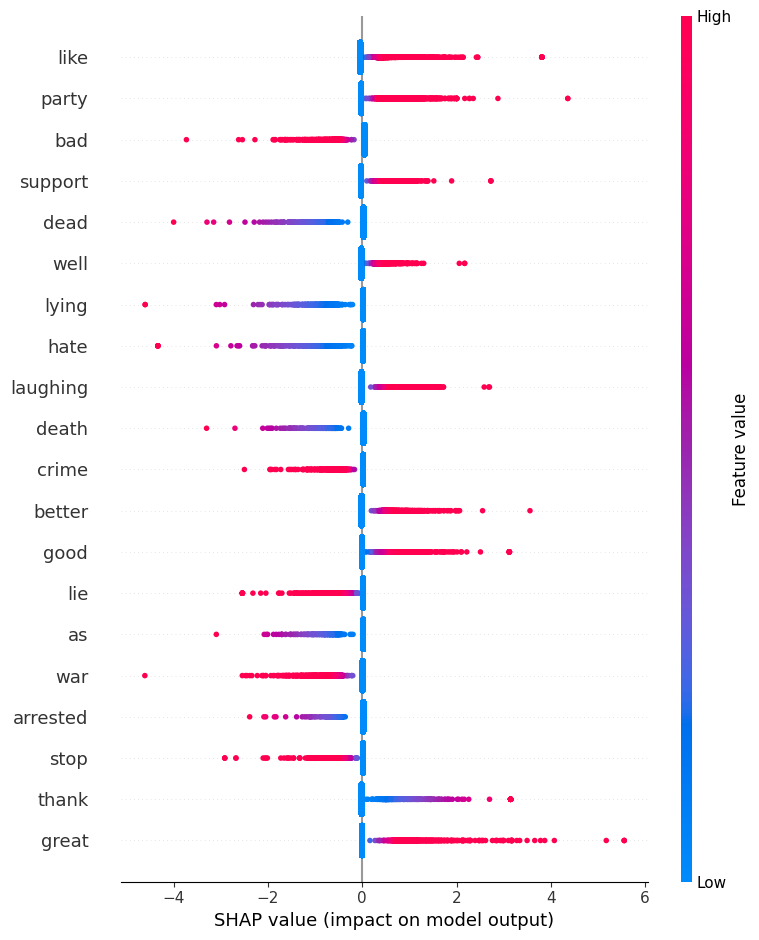

In [24]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_train = train[train['party'] == 'democrat'].copy()
democrat_predict = predictions[predictions['party'] == 'democrat'].copy()

X_train, y_train = democrat_train['clean_text'], democrat_train['sentiment']
X_test, y_test = democrat_predict['clean_text'], democrat_predict['sentiment']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

democrat_tfidf = tfidf.transform(X_sample_test)

democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)

dem_feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=dem_feature_names,
    title="SHAP Summary: Democratic Sentiment Classification"
)

In [25]:
class_labels = clf.classes_
print(class_labels)

['negative' 'positive']


In [26]:
feature_importance = []

for i, feature_name in enumerate(dem_feature_names):
    feature_vals = democrat_tfidf_dense[:, i]
    shap_vals = shap_values[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Mean_SHAP_When_Present': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

dem_df = pd.DataFrame(feature_importance).sort_values(
    by='Mean_SHAP_When_Present', 
    ascending=False
)

print("Directional Importance (top 10 pushing toward positive sentiment):")
dem_df.head(10)


Directional Importance (top 10 pushing toward positive sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
740,awesome,1.626253,70,positive
5283,lmao,1.415958,112,positive
5354,love,1.364953,559,positive
1931,congratulation,1.304814,31,positive
5285,lmfao,1.228882,32,positive
4098,hahaha,1.225003,32,positive
393,amazing,1.216857,117,positive
895,best,1.214894,511,positive
4035,greatest,1.213550,61,positive
4017,great,1.180623,592,positive


In [27]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
dem_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
4477,humiliation,-1.146744,10,negative
9575,worst,-1.157739,317,negative
2898,doomed,-1.158570,15,negative
3248,evil,-1.190754,307,negative
3723,fucked,-1.229075,64,negative
4262,hated,-1.246660,44,negative
9639,wtf,-1.291687,116,negative
6496,pissed,-1.334221,60,negative
1524,ca win,-1.345024,28,negative
4324,hell,-1.676837,332,negative


In [28]:
y_pred_sample = model.predict(X_sample_test)
misclassified_mask = y_pred_sample != y_sample_test.values

print(f"Overall Accuracy: {(~misclassified_mask).mean():.2%}")
print(f"Misclassified: {misclassified_mask.sum()} out of {len(y_pred_sample)}")

Overall Accuracy: 100.00%
Misclassified: 0 out of 50000


In [29]:
max_shap_per_instance = np.abs(shap_values).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0

print(f"\nInstances with single feature |SHAP| > 2.0: {high_leverage_mask.sum()} / {len(y_pred_sample)}")
print(f"Percentage: {high_leverage_mask.sum() / len(y_pred_sample) * 100:.2f}%")

high_leverage_and_wrong = high_leverage_mask & misclassified_mask
high_leverage_and_correct = high_leverage_mask & ~misclassified_mask

print(f"\nHigh-leverage AND correct: {high_leverage_and_correct.sum()}")
print(f"High-leverage AND wrong: {high_leverage_and_wrong.sum()}")

if high_leverage_and_wrong.sum() > 0:
    error_rate_high_leverage = high_leverage_and_wrong.sum() / high_leverage_mask.sum() * 100
    print(f"Error rate among high-leverage: {error_rate_high_leverage:.2f}%")
else:
    print(f"Error rate among high-leverage: 0.00%")

if high_leverage_mask.sum() > 0:    
    if high_leverage_and_correct.sum() > 0:
        print("\nCorrect high-leverage predictions:")
        for i in np.where(high_leverage_and_correct)[0][:3]:
            max_feature_idx = np.argmax(np.abs(shap_values[i]))
            max_shap = shap_values[i, max_feature_idx]
            feature_name = dem_feature_names[max_feature_idx]  # Changed: use dem_feature_names
            true_label = y_sample_test.iloc[i]
            pred_label = y_pred_sample[i]
            
            # Get original text
            original_idx = sample_indices[i]
            original_text = democrat_predict.loc[original_idx, 'text'] if original_idx in democrat_predict.index else "N/A"
            
            print(f"\nSample {i}:")
            print(f"Dominant: '{feature_name}' (SHAP: {max_shap:+.4f})")
            print(f"True: {true_label} | Predicted: {pred_label}")
            print(f"Cleaned: {X_sample_test.iloc[i][:150]}...")
            print(f"Original: {original_text[:150]}...")
    
    # Show wrong ones if they exist
    if high_leverage_and_wrong.sum() > 0:
        print("\Wrong high-leverage predictions:")
        for i in np.where(high_leverage_and_wrong)[0][:3]:
            max_feature_idx = np.argmax(np.abs(shap_values[i]))
            max_shap = shap_values[i, max_feature_idx]
            feature_name = dem_feature_names[max_feature_idx]  # Changed: use dem_feature_names
            true_label = y_sample_test.iloc[i]
            pred_label = y_pred_sample[i]
            
            # Get original text
            original_idx = sample_indices[i]
            original_text = democrat_predict.loc[original_idx, 'text'] if original_idx in democrat_predict.index else "N/A"
            
            print(f"\nSample {i}:")
            print(f"Dominant: '{feature_name}' (SHAP: {max_shap:+.4f})")
            print(f"True: {true_label} | Predicted: {pred_label}")
            print(f"Cleaned: {X_sample_test.iloc[i][:150]}...")
            print(f"Original: {original_text[:150]}...")




Instances with single feature |SHAP| > 2.0: 1209 / 50000
Percentage: 2.42%

High-leverage AND correct: 1209
High-leverage AND wrong: 0
Error rate among high-leverage: 0.00%

Correct high-leverage predictions:

Sample 1:
Dominant: 'fight' (SHAP: -2.0469)
True: negative | Predicted: negative
Cleaned: fight...
Original: Fight https://t.co/Ds5ap3CL5G...

Sample 39:
Dominant: 'yes' (SHAP: +3.1037)
True: positive | Predicted: positive
Cleaned: yes...
Original: @krew_ny Yes he does...

Sample 71:
Dominant: 'best' (SHAP: +2.4670)
True: positive | Predicted: positive
Cleaned: best maya rudolph kamala harris part via...
Original: The Best of Maya Rudolph as Kamala Harris - Part 2 https://t.co/ydeRIBjT6K via @YouTube...


## Republican Sentiment Classifier

50000
9574156
0.005222392449005427


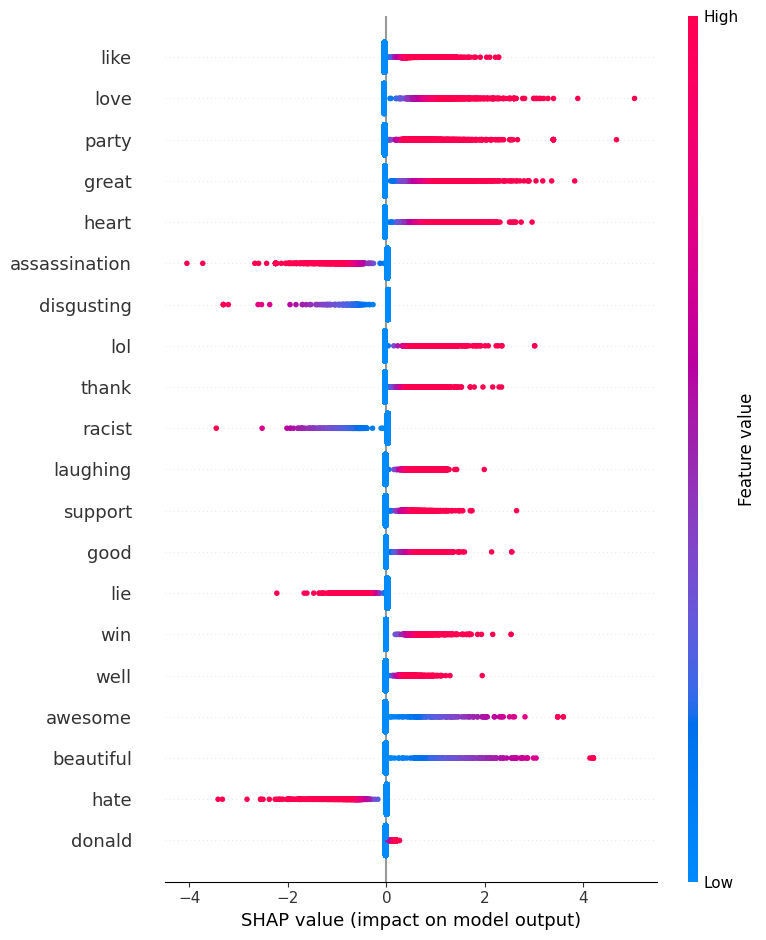

In [30]:
model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

rep_train = train[train['party'] == 'republican'].copy()
rep_predict = predictions[predictions['party'] == 'republican'].copy()

X_train, y_train = rep_train['clean_text'], rep_train['sentiment']
X_test, y_test = rep_predict['clean_text'], rep_predict['sentiment']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

republican_tfidf = tfidf.transform(X_sample_test)
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Republican Sentiment Classification"
)

In [31]:
feature_importance = []

for i, feature_name in enumerate(dem_feature_names):
    feature_vals = republican_tfidf_dense[:, i]
    shap_vals = shap_values[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Mean_SHAP_When_Present': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

rep_df = pd.DataFrame(feature_importance).sort_values(
    by='Mean_SHAP_When_Present', 
    ascending=False
)

print("Directional Importance (top 10 pushing toward positive sentiment):")
rep_df.head(10)


Directional Importance (top 10 pushing toward positive sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
734,az,1.797786,4,positive
805,barely,1.509259,229,positive
695,attempt life,1.255054,128,positive
861,behind scene,1.178480,482,positive
341,align,1.105605,171,positive
3592,fixed,1.102807,32,positive
9587,would take,1.100726,217,positive
9457,wisconsin,1.082070,49,positive
5783,mr president,1.053212,16,positive
3523,fight back,1.047487,115,positive


In [32]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
rep_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
6609,pray,-1.079360,323,negative
7324,rose,-1.085238,23,negative
3166,entire world,-1.090082,344,negative
7588,sexual abuse,-1.115694,23,negative
7518,seek,-1.168635,185,negative
1295,blaming,-1.226302,14,negative
2249,dear,-1.230302,62,negative
1329,blue blue,-1.255206,56,negative
9605,wrong side,-1.282041,81,negative
3801,genuine,-1.383791,269,negative


## Cross Party sentiment analysis

In [40]:
TOP_N = 100

# Get top positive features for each party
dem_positive = set(dem_df.head(TOP_N)['Feature'])
rep_positive = set(rep_df.head(TOP_N)['Feature'])

# Find overlaps and differences
universal_positive = dem_positive & rep_positive
dem_only_positive = dem_positive - rep_positive
rep_only_positive = rep_positive - dem_positive

print(f"\nPositive Sentiment Analysis:")
print(f"Universal positive markers: {len(universal_positive)} ({len(universal_positive)/TOP_N*100:.0f}%)")
print(f"Democrat-only positive: {len(dem_only_positive)}")
print(f"Republican-only positive: {len(rep_only_positive)}")

if universal_positive:
    print(f"\nUniversal positive features):")
    comparison_data = []
    for feature in universal_positive:
        dem_shap = dem_df[dem_df['Feature']==feature]['Mean_SHAP_When_Present'].values[0]
        rep_shap = rep_df[rep_df['Feature']==feature]['Mean_SHAP_When_Present'].values[0]
        comparison_data.append({
            'Feature': feature,
            'Dem_SHAP': dem_shap,
            'Rep_SHAP': rep_shap,
            'Difference': abs(dem_shap - rep_shap)
        })
    
    comp_df = pd.DataFrame(comparison_data).sort_values('Dem_SHAP', ascending=False)
    print(comp_df.to_string(index=False))

if dem_only_positive:
    print(f"\nDemocrat-specific positive features:")
    dem_specific = dem_df[dem_df['Feature'].isin(dem_only_positive)].head(10)
    print(dem_specific[['Feature', 'Mean_SHAP_When_Present', 'Count_Present']].to_string(index=False))

if rep_only_positive:
    print(f"\n Republican-specific positive features:")
    rep_specific = rep_df[rep_df['Feature'].isin(rep_only_positive)].head(10)
    print(rep_specific[['Feature', 'Mean_SHAP_When_Present', 'Count_Present']].to_string(index=False))



Positive Sentiment Analysis:
Universal positive markers: 0 (0%)
Democrat-only positive: 100
Republican-only positive: 100

Democrat-specific positive features:
       Feature  Mean_SHAP_When_Present  Count_Present
       awesome                1.626253             70
          lmao                1.415958            112
          love                1.364953            559
congratulation                1.304814             31
         lmfao                1.228882             32
        hahaha                1.225003             32
       amazing                1.216857            117
          best                1.214894            511
      greatest                1.213550             61
         great                1.180623            592

 Republican-specific positive features:
     Feature  Mean_SHAP_When_Present  Count_Present
          az                1.797786              4
      barely                1.509259            229
attempt life                1.255054            

In [42]:
dem_negative = set(dem_df.tail(TOP_N)['Feature'])
rep_negative = set(rep_df.tail(TOP_N)['Feature'])

# Find overlaps and differences
universal_negative = dem_negative & rep_negative
dem_only_negative = dem_negative - rep_negative
rep_only_negative = rep_negative - dem_negative

print(f"\nNegative Sentiment Analysis:")
print(f"Universal negative markers: {len(universal_negative)} ({len(universal_negative)/TOP_N*100:.0f}%)")
print(f"Democrat-only negative: {len(dem_only_negative)}")
print(f"Republican-only negative: {len(rep_only_negative)}")

if universal_negative:
    print(f"\nUniversal Negative Features:")
    comparison_data = []
    for feature in universal_negative:
        dem_shap = dem_df[dem_df['Feature']==feature]['Mean_SHAP_When_Present'].values[0]
        rep_shap = rep_df[rep_df['Feature']==feature]['Mean_SHAP_When_Present'].values[0]
        comparison_data.append({
            'Feature': feature,
            'Dem_SHAP': dem_shap,
            'Rep_SHAP': rep_shap,
            'Difference': abs(dem_shap - rep_shap)
        })
    
    comp_df = pd.DataFrame(comparison_data).sort_values('Dem_SHAP')
    print(comp_df.to_string(index=False))

if dem_only_negative:
    print(f"\nDem-specific negative features:")
    dem_specific = dem_df[dem_df['Feature'].isin(dem_only_negative)].tail(10)
    print(dem_specific[['Feature', 'Mean_SHAP_When_Present', 'Count_Present']].to_string(index=False))

if rep_only_negative:
    print(f"\nRepublican-specific negative features:")
    rep_specific = rep_df[rep_df['Feature'].isin(rep_only_negative)].tail(10)
    print(rep_specific[['Feature', 'Mean_SHAP_When_Present', 'Count_Present']].to_string(index=False))



Negative Sentiment Analysis:
Universal negative markers: 3 (3%)
Democrat-only negative: 97
Republican-only negative: 97

Universal Negative Features:
Feature  Dem_SHAP  Rep_SHAP  Difference
    wtf -1.291687 -0.956344    0.335342
    mad -1.007989 -0.817166    0.190823
  awful -0.803043 -0.867395    0.064352

Dem-specific negative features:
    Feature  Mean_SHAP_When_Present  Count_Present
    suicide               -1.146587             26
humiliation               -1.146744             10
      worst               -1.157739            317
     doomed               -1.158570             15
       evil               -1.190754            307
     fucked               -1.229075             64
      hated               -1.246660             44
     pissed               -1.334221             60
     ca win               -1.345024             28
       hell               -1.676837            332

Republican-specific negative features:
     Feature  Mean_SHAP_When_Present  Count_Present
   

In [38]:
overlap_pos_pct = len(universal_positive)/TOP_N*100
overlap_neg_pct = len(universal_negative)/TOP_N*100

print(f"  Positive sentiment overlap: {overlap_pos_pct:.0f}%")
print(f"  Negative sentiment overlap: {overlap_neg_pct:.0f}%")

if overlap_pos_pct > 70 and overlap_neg_pct > 70:
    print("Both parties express sentiment using similar language.")
    print("Sentiment markers are largely universal across political affiliation.")
elif overlap_pos_pct < 30 or overlap_neg_pct < 30:
    print("Democrats and Republicans express sentiment very differently.")
    print("Strong evidence of party-specific sentiment language.")
else:
    print("Mix of universal and party-specific sentiment markers.")
    print("Some emotional expressions are shared, others are partisan.")



📈 OVERALL FINDINGS:
  Positive sentiment overlap: 0%
  Negative sentiment overlap: 3%
  LOW OVERLAP: Democrats and Republicans express sentiment very differently.
  Strong evidence of party-specific sentiment language.
